# 📞 Customer Call Classification System

## 📌 Step 1: Import Libraries
This cell imports all required libraries for audio processing, NLP, ML modeling, and visualization.

- os, re → file handling & text processing  
- pandas → data handling  
- matplotlib → visualization  
- speech_recognition → audio to text conversion  
- nltk → NLP preprocessing  
- sklearn → ML model building

In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import speech_recognition as sr

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Khushi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Khushi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## 🎤 Step 2: Audio Transcription Function

This function converts `.wav` audio files into text using Google Speech Recognition API.

### Process:
- Load audio file
- Record audio
- Convert speech → text
- Handle errors safely (return empty string if failure)

In [2]:
recognizer = sr.Recognizer()

def transcribe_audio(file_path):
    try:
        with sr.AudioFile(file_path) as source:
            audio = recognizer.record(source)
        text = recognizer.recognize_google(audio)
    except Exception as e:
        text = ""
    return text

## 🧠 Step 3: Rule-Based Keyword Classification

This function classifies text into:
- 🔴 Urgent
- 🟢 Closed
- 🔵 Open

### Logic:
- Uses predefined keyword lists
- Matches keywords in lowercase text
- Returns category based on priority:
  Urgent > Closed > Open

In [3]:
def keyword_rule(text):
    text = text.lower()
    
    # URGENT
    urgent_keywords = [
        "not working", "issue", "problem", "error",
        "trouble", "failed", "failure",
        "dissatisfied","refund", "return", "complaint",
        "unhappy", "complain","angry", "delay", "bad", "worst"
    ]
    
    # CLOSED
    closed_keywords = [
        "resolved", "fixed", "solved",
        "thank you", "thanks",
        "working fine", "working now",
        "happy", "satisfied"
        # ,"pleased","good", "great"
    ]

    #OPEN
    open_keywords = [
        "need", "help", "support",
        "enquire", "inquiry", "question",
        "request", "assist", "information"
    ]
    
    if any(word in text for word in urgent_keywords):
        return "Urgent"
    
    elif any(word in text for word in closed_keywords):
        return "Closed"
    
    elif any(word in text for word in open_keywords):
        return "Open"
    
    else:
        return None

## 📂 Step 4: Audio Dataset Processing

### Process:
- Load all `.wav` files from folder
- Convert speech → text
- Apply rule-based classification
- Store results in structured dataset

### Output Columns:
- file name
- transcription
- category

In [4]:
folder_path = "./calls_audio"

data = []

for file in os.listdir(folder_path):
    if file.endswith(".wav"):
        path = os.path.join(folder_path, file)
        
        text = transcribe_audio(path)
        
        if text.strip() == "":
            continue   
        
        category = keyword_rule(text)
        
        if category is None:
            category = "Open"
        
        data.append({
            "file": file,
            "transcription": text,
            "category": category
        })

df = pd.DataFrame(data)

print("Data Ready:", df.shape)
print(df.head())

Data Ready: (20, 3)
                    file                                      transcription  \
0  call_recording_01.wav  hello I am Sharmila I am calling to enquire ab...   
1  call_recording_02.wav  I am extremely dissatisfied with my recent ord...   
2  call_recording_03.wav  hi this is Maria Rotary guess I am having trou...   
3  call_recording_04.wav  I just wanted to call and say how please I am ...   
4  call_recording_05.wav  hello my name is Jessica brown I would like to...   

  category  
0     Open  
1   Urgent  
2   Urgent  
3   Closed  
4     Open  


## 🧹 Step 5: Text Cleaning

### Steps:
- Convert text to lowercase
- Remove special characters
- Remove stopwords
- Apply lemmatization

### Purpose:
To normalize text for better ML model performance.

In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return " ".join(words)

df['clean_text'] = df['transcription'].apply(clean_text)

## 🔢 Step 6: Feature Engineering (TF-IDF)

### Method:
- Convert text into numerical vectors
- Use TF-IDF (1–2 grams)
- Limit features to top 500

### Purpose:
To represent text data in machine-readable format.

In [6]:
tfidf = TfidfVectorizer(max_features=500, ngram_range=(1,2))

X = tfidf.fit_transform(df['clean_text'])
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 🤖 Step 7: Model Training

### Steps:
- Split data into training (80%) and testing (20%)
- Train Multinomial Naive Bayes model

### Why Naive Bayes?
- Fast
- Effective for text classification
- Works well with TF-IDF features

In [7]:
model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


## 📊 Step 8: Model Evaluation

### Metrics:
- Accuracy Score
- Classification Report (Precision, Recall, F1-score)

### Purpose:
To measure how well the model performs on unseen data.

In [8]:
y_pred = model.predict(X_test)

print("\nMODEL PERFORMANCE")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


MODEL PERFORMANCE
Accuracy: 1.0
              precision    recall  f1-score   support

        Open       1.00      1.00      1.00         2
      Urgent       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



## 🧠 Step 9: Final Prediction System (Hybrid Model)

### Logic:
1. First apply rule-based classification
2. If no keyword match → use ML model

### Advantage:
- Faster predictions for obvious cases
- Smarter handling of complex cases

In [9]:
def predict(text):
    
    rule_output = keyword_rule(text)
    
    if rule_output is not None:
        return rule_output
    
    text_clean = clean_text(text)
    vec = tfidf.transform([text_clean])
    
    return model.predict(vec)[0]

## 🧪 Step 10: Model Testing

### Test Inputs:
- Sample customer sentences are used to verify predictions.

### Output:
- Predicted category for each input text

In [10]:
print("\nTESTING MODEL")

tests = [
    "my device is not working",
    "thank you issue resolved",
    "i need help with installation",
    "very dissatisfied with service",
    "everything is working fine now"
]

for t in tests:
    print(f"\nInput: {t}")
    print("Prediction:", predict(t))


TESTING MODEL

Input: my device is not working
Prediction: Urgent

Input: thank you issue resolved
Prediction: Urgent

Input: i need help with installation
Prediction: Open

Input: very dissatisfied with service
Prediction: Urgent

Input: everything is working fine now
Prediction: Closed


## 💾 Step 11: Save Final Dataset

### Action:
- Export final dataframe to CSV file

### File:
Output.csv contains:
- transcription
- predicted category

In [11]:
df.to_csv("Output.csv", index=False)

print("\nFINAL PROJECT COMPLETED")


FINAL PROJECT COMPLETED


## 📊 Step 12: Data Visualization

### Charts:
- Bar chart → Category distribution
- Pie chart → Percentage distribution

### Purpose:
To understand dataset balance and insights visually.

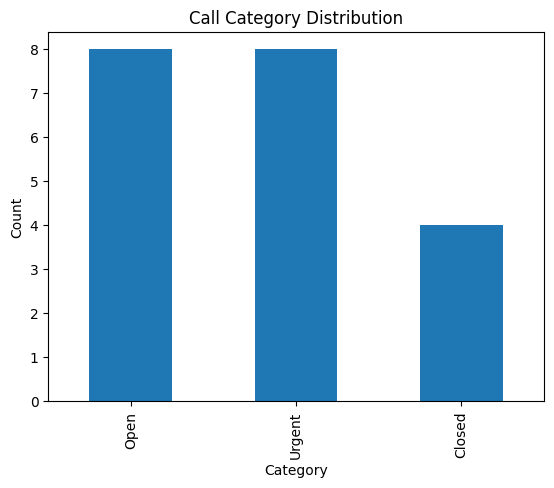

In [12]:
df['category'].value_counts().plot(kind='bar')
plt.title("Call Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

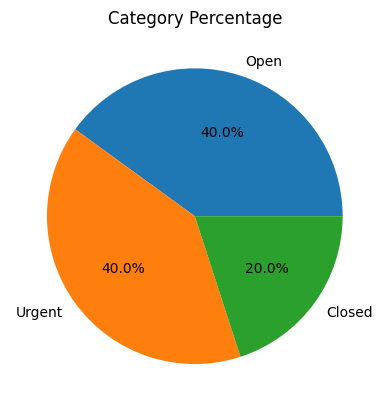

In [13]:
df['category'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Category Percentage")
plt.show()

## 🔍 Step 13: Model Performance Visualization

### Confusion Matrix:
- Compares actual vs predicted labels
- Helps identify misclassifications

### Purpose:
To evaluate model accuracy visually.

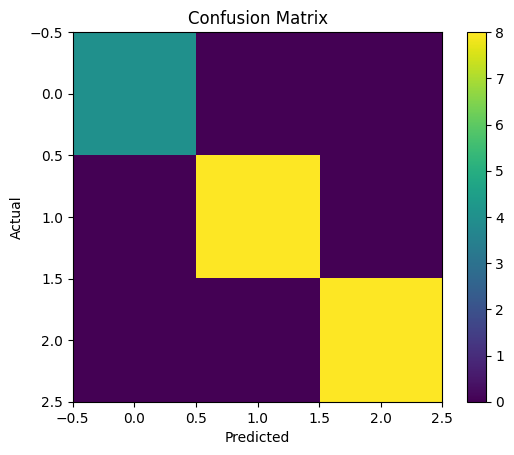

In [14]:
y_pred = [predict(t) for t in df['transcription']]
cm = confusion_matrix(df['category'], y_pred)
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

## 🎧 Step 14: Real-Time Prediction

### Process:
- Take a single audio file
- Convert speech → text
- Predict category using hybrid model

### Output:
- Transcription
- Final predicted class

In [15]:
file_path = "./calls_audio/call_recording_01.wav"
text = transcribe_audio(file_path)
print("Transcription:", text)
print("Prediction:", predict(text))

Transcription: hello I am Sharmila I am calling to enquire about the AC 7892 air conditioner unit I sort on your website and I had a few questions first what's the BTU rating and second does it come with a remote control or is that sold separately
Prediction: Open
